# Evaluación 2 — Reconstrucción de señales con una capa Fourier
**ID personalizado: 9955**


Contenido:
1. Carga de datos.
2. Construcción de la capa Fourier y verificación contra la DFT.
3. Definición del modelo en JAX (cada función documentada).
4. Entrenamiento con las dos inicializaciones, en los tres regímenes, 3000 iteraciones.
5. Comparación de curvas de pérdida, con foco en la velocidad de convergencia del régimen 0.
6. Reconstrucción visual (señal original vs. reconstruida).
7. Análisis de compresión: cuántos coeficientes de la capa Fourier concentran el 95% de la energía.
8. Conclusiones, con números concretos obtenidos de la corrida.

In [24]:
mpl.rcParams.update({
    "text.usetex": True,            # Activa el renderizado de LaTeX
    "font.family": "serif",         # Usa familia serif
    "font.serif": ["Computer Modern Roman"], # Fuente clásica de LaTeX
    "font.size": 14,                # Tamaño de fuente general más grande

    # Ejes y Ticks
    "axes.labelsize": 16,           # Tamaño de etiquetas (x, y)
    "axes.titlesize": 18,           # Tamaño del título
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,    # Mostrar ticks menores en X
    "ytick.minor.visible": True,    # Mostrar ticks menores en Y
    "xtick.direction": "in",        # Ticks hacia adentro (estilo clásico)
    "ytick.direction": "in",

    # Estética de la figura
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

print('Configuración OK')

Configuración OK


In [25]:
!pip install --upgrade pip
!pip install numpy matplotlib "jax[gpu]"


In [26]:
# ============================================================
# Importes
# ============================================================
# numpy       -> generación/carga de datos y álgebra fuera de JAX
# matplotlib  -> todas las gráficas
# jax         -> autodiferenciación y entrenamiento de la red
# ============================================================
import os
import math
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random

print("JAX version:", jax.__version__)
print("Dispositivo:", jax.devices())

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


JAX version: 0.10.2
Dispositivo: [CpuDevice(id=0)]


## Parámetros globales

- `N = 256`: longitud de cada señal (número de muestras temporales).
- `K = 20`: número de frecuencias de la capa Fourier ⇒ la capa produce `2K = 40` salidas (una fila coseno y una seno por cada `k`).
- `LR = 0.05`: tasa de aprendizaje sugerida.
- `N_ITERS = 3000`: iteraciones de descenso de gradiente pedidas en el enunciado.
- `SEED = 9955`: semilla ligada al ID, para que todo el notebook sea reproducible.
- `DATA_PATH`: ruta al `.npz` generado con el script del ID 9955 (15 señales × 3 regímenes = 45 señales).

In [28]:
# ============================================================
# Parámetros globales
# ============================================================
N = 256            # longitud de cada señal
K = 20             # número de frecuencias de la capa Fourier
TWO_K = 2 * K       # tamaño de salida de la primera capa (cos + sin por cada k)
LR = 0.05           # learning rate
N_ITERS = 3000      # iteraciones de entrenamiento
SEED = 9955         # semilla del ID
REGIMES = [0, 1, 2]
N_PER_REGIME = 15

# Ruta esperada del archivo de datos generado por el script del ID 9955.
# AJUSTAR esta ruta a la ubicación real del archivo en su máquina.
DATA_PATH = r"/mnt/c/Users/migue/OneDrive - Universidad Nacional de Colombia/U Nacional/Programacion Cientifica/datos_9955.npz"

print("N =", N, " K =", K, " 2K =", TWO_K, " LR =", LR, " N_ITERS =", N_ITERS, " SEED =", SEED)

N = 256  K = 20  2K = 40  LR = 0.05  N_ITERS = 3000  SEED = 9955


## Carga de datos

Regímenes (según `μ`):
- Régimen 0: `μ = 0` (sin dispersión, frecuencias bajas).
- Régimen 1: `μ` intermedio.
- Régimen 2: `μ` grande (frecuencias altas).

Para que el régimen 0 coincida exactamente con la grilla de frecuencias de la capa Fourier (`2πk/N`), se usa `c = 2π/N`: así, cuando `μ = 0`, `ω(k) = c·k = 2πk/N`, que es precisamente la frecuencia de la fila `k` de `W1`. Cuando `μ > 0`, las frecuencias reales se **desplazan** de esa grilla — ahí es donde se espera que la ventaja de partir en Fourier se reduzca.

In [29]:
# ============================================================
# - c = 2*pi/N: hace que el regimen 0 (mu=0) caiga exactamente
#    sobre la grilla de frecuencias de la capa Fourier.
# - mu_values: separacion creciente de esa grilla para regimen 1 y 2.
# - Cada señal es una suma de "n_modos" cosenos con numero de onda k
#    aleatorio, amplitud a_j y fase phi_j aleatorias (Parte I.3).
# Devuelve X (n_senales, N), y (etiquetas de regimen), t (vector de tiempo)
# ============================================================

data = np.load(DATA_PATH, allow_pickle=True)
print("Cargado archivo:", DATA_PATH)
print("Claves en el .npz:", data.files)
keys = data.files
X = data['X'] if 'X' in keys else (data['signals'] if 'signals' in keys else data[keys[0]])
y = data['y'] if 'y' in keys else (data['labels'] if 'labels' in keys else data[keys[1]])
t = data['t'] if 't' in keys else np.arange(N)

X = np.asarray(X, dtype=np.float32)
y = np.asarray(y).astype(int)

print("X shape:", X.shape, " y shape:", y.shape)

data_by_regime = {r: X[y == r] for r in REGIMES}
for r in REGIMES:
    print(f"Régimen {r}: {data_by_regime[r].shape[0]} señales (esperadas: {N_PER_REGIME})")

Cargado archivo: /mnt/c/Users/migue/OneDrive - Universidad Nacional de Colombia/U Nacional/Programacion Cientifica/datos_9955.npz
Claves en el .npz: ['X', 'y', 't', 'meta']
X shape: (45, 256)  y shape: (45,)
Régimen 0: 15 señales (esperadas: 15)
Régimen 1: 15 señales (esperadas: 15)
Régimen 2: 15 señales (esperadas: 15)


### Vistazo rápido a los datos

Una señal de ejemplo por régimen, para confirmar visualmente que el régimen 0 oscila más lento y el régimen 2 más rápido (como predice `ω(k) = sqrt(c²k² + μ²)`).

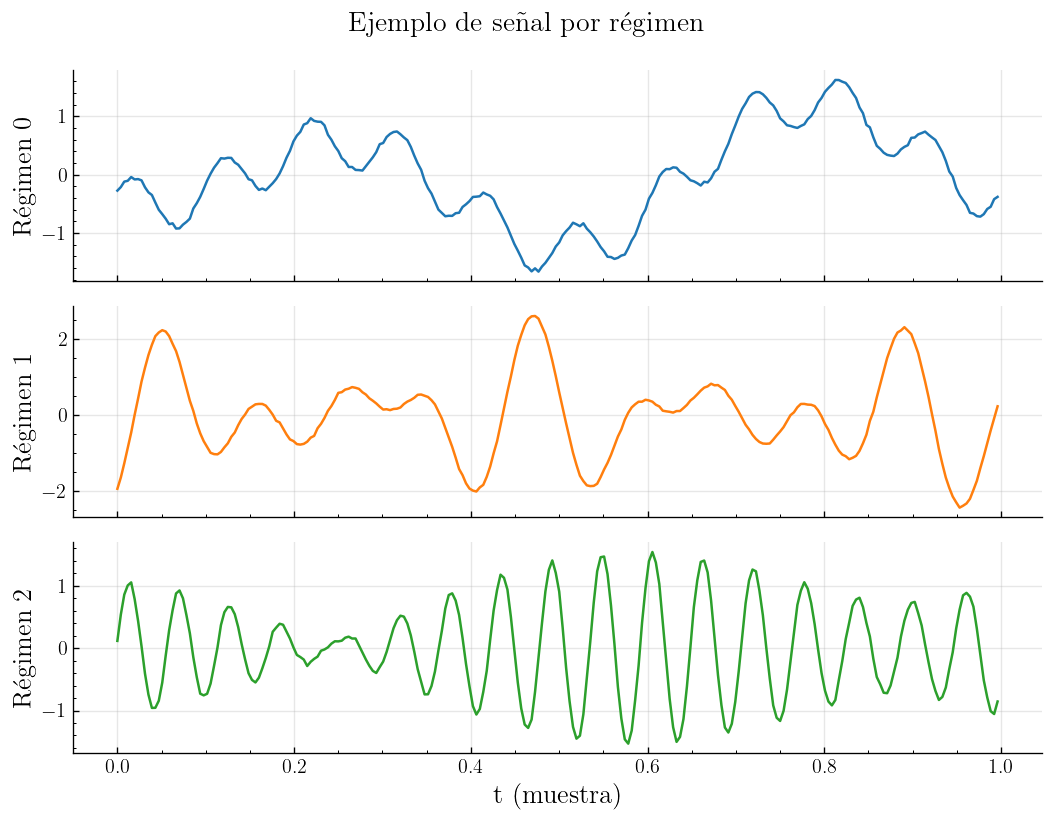

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for r, ax in zip(REGIMES, axes):
    ax.plot(t[:N], data_by_regime[r][0], color=f"C{r}")
    ax.set_ylabel(f"Régimen {r}")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("t (muestra)")
fig.suptitle("Ejemplo de señal por régimen")
plt.tight_layout()
plt.show()

## Capa Fourier ($W_1$)

$W_1 \in \mathbb{R}^{2K \times N}$ se construye con:
- fila $2k-2$: $\cos(2\pi k t / N)$
- fila $2k-1$: $\sin(2\pi k t / N)$

para $k = 1, \dots, K$. El producto $W_1 x$ da, para cada $k$, la proyección de la señal sobre coseno y seno de frecuencia $k$ — **exactamente** lo que hace la DFT.

**Verificación:** la DFT de $x$ es $X(k) = \sum_t x(t) e^{-i2\pi kt/N} = \sum_t x(t)\cos(2\pi kt/N) - i \sum_t x(t)\sin(2\pi kt/N)$.

Por lo tanto se debe cumplir:
- $\mathrm{Re}(X(k)) = (W_1 x)_{\cos,k}$
- $\mathrm{Im}(X(k)) = -(W_1 x)_{\sin,k}$

Abajo se comprueba numéricamente con `np.allclose`.

In [31]:
# ============================================================
# fourier_W1
# ------------------------------------------------------------
# Construye la matriz de la capa Fourier (2K x N).
# Fila 2k-2 = cos(2*pi*k*t/N), fila 2k-1 = sin(2*pi*k*t/N), k=1..K
# ============================================================
def fourier_W1(N, K):
    tt = np.arange(N)
    rows = []
    for k in range(1, K + 1):
        omega = 2 * math.pi * k / N
        rows.append(np.cos(omega * tt))
        rows.append(np.sin(omega * tt))
    return np.stack(rows, axis=0).astype(np.float32)


W1_fourier = fourier_W1(N, K)
print("W1_fourier shape:", W1_fourier.shape)

# --- Verificación contra la DFT ---
x0 = data_by_regime[0][0]
proj = W1_fourier @ x0            # (2K,) -> [cos_1, sin_1, cos_2, sin_2, ...]
Xk = np.fft.fft(x0)               # DFT completa

proj_cos = proj[0::2]             # componentes coseno, k=1..K
proj_sin = proj[1::2]             # componentes seno, k=1..K
re_dft = np.real(Xk[1:K + 1])
im_dft = np.imag(Xk[1:K + 1])

print("max|Re(DFT_k) - proj_cos_k| =", np.max(np.abs(re_dft - proj_cos)))
print("max|Im(DFT_k) - (-proj_sin_k)| =", np.max(np.abs(im_dft - (-proj_sin))))

ok = np.allclose(re_dft, proj_cos, atol=1e-3) and np.allclose(im_dft, -proj_sin, atol=1e-3)
print("¿La capa Fourier reproduce la DFT?", ok)

W1_fourier shape: (40, 256)
max|Re(DFT_k) - proj_cos_k| = 7.6293945e-06
max|Im(DFT_k) - (-proj_sin_k)| = 3.8146973e-06
¿La capa Fourier reproduce la DFT? True


## Modelo y funciones de entrenamiento (JAX)

Arquitectura: $\hat x = W_2\,\tanh(W_1 x + b_1) + b_2$, con $W_1 \in \mathbb{R}^{2K\times N}$, $W_2 \in \mathbb{R}^{N \times 2K}$.

A continuación se documenta cada función:

- **`init_params`**: crea los pesos iniciales. Si `w1_init="fourier"`, $W_1$ arranca siendo la matriz de Fourier construida arriba; si `"random"`, arranca con pesos gaussianos pequeños. $W_2$ y los sesgos siempre arrancan aleatorios/en cero — lo único que cambia entre los dos experimentos es el punto de partida de $W_1$ (tal como pide el enunciado), y $W_1$ se sigue entrenando en ambos casos.
- **`forward`**: aplica la red a una sola señal `x` y devuelve la reconstrucción $\hat x$.
- **`loss_fn`**: error cuadrático medio $\mathcal L = \frac1N\|\hat x - x\|^2$, promediado además sobre todas las señales del batch (`vmap` aplica `forward` a cada señal del batch en paralelo).
- **`sgd_step`**: un paso de descenso de gradiente: calcula $\nabla_\theta \mathcal L$ con `jax.grad` y actualiza cada parámetro con $\theta \leftarrow \theta - \eta\nabla_\theta\mathcal L$. Está compilado con `@jit` para que corra rápido.
- **`train_on_signals`**: entrena la red sobre un conjunto de señales durante `N_ITERS` iteraciones, guardando la pérdida cada 10 iteraciones para poder graficar su evolución.

In [32]:
# ============================================================
# init_params
# ------------------------------------------------------------
# Crea los parámetros iniciales de la red.
#   w1_init = "fourier" -> W1 arranca como la matriz de Fourier (fija arriba)
#   w1_init = "random"  -> W1 arranca con pesos gaussianos pequeños N(0, 0.1^2)
# W2 y los sesgos b1, b2 se inicializan igual en ambos casos: lo único
# que varia entre los dos experimentos es el punto de partida de W1.
# ============================================================
def init_params(key, w1_init="fourier"):
    k1, k2 = random.split(key)
    if w1_init == "fourier":
        W1 = jnp.array(W1_fourier)
    elif w1_init == "random":
        W1 = random.normal(k1, (TWO_K, N)) * 0.1
    else:
        raise ValueError('w1_init debe ser "fourier" o "random"')
    b1 = jnp.zeros((TWO_K,))
    W2 = random.normal(k2, (N, TWO_K)) * 0.1
    b2 = jnp.zeros((N,))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


# ============================================================
# forward
# ------------------------------------------------------------
# Aplica la red a UNA señal x (vector de tamaño N) y devuelve x_hat.
#   z = W1 x + b1        -> proyección sobre las 2K "bases" aprendidas
#   h = tanh(z)           -> no linealidad
#   x_hat = W2 h + b2     -> reconstrucción en el dominio del tiempo
# ============================================================
def forward(params, x):
    z = jnp.dot(params["W1"], x) + params["b1"]
    h = jnp.tanh(z)
    x_hat = jnp.dot(params["W2"], h) + params["b2"]
    return x_hat


# ============================================================
# loss_fn
# ------------------------------------------------------------
# Error cuadratico medio, tal como en el enunciado:
#   L = (1/N) * ||x_hat - x||^2   para cada senal
# y se promedia sobre todas las señales del batch.
# vmap aplica `forward` a cada fila del batch sin necesidad de un for-loop.
# ============================================================
def loss_fn(params, batch):
    preds = vmap(lambda x: forward(params, x))(batch)
    per_signal_mse = jnp.mean((preds - batch) ** 2, axis=1)  # (1/N)||x_hat-x||^2 por señal
    return jnp.mean(per_signal_mse)                          # promedio sobre el batch


# ============================================================
# sgd_step
# ------------------------------------------------------------
# Un paso de descenso de gradiente sobre TODOS los parametros:
#   theta <- theta - lr * dL/dtheta
# jax.grad calcula el gradiente de loss_fn respecto a params (dict).
# @jit compila la funcion para que las 3000 iteraciones corran rapido.
# ============================================================
@jit
def sgd_step(params, batch, lr):
    grads = jax.grad(loss_fn)(params, batch)
    return {k: params[k] - lr * grads[k] for k in params}


# ============================================================
# train_on_signals
# ------------------------------------------------------------
# Entrena la red sobre `signals` (todas las señales de un régimen)
# durante N_ITERS iteraciones de descenso de gradiente de batch completo.
# Guarda (iteracion, perdida) cada 10 pasos para poder graficar la curva.
# w1_init_label: "fourier" o "random", se usa para fijar el punto de partida
# y para usar una semilla distinta en cada caso (reproducibilidad).
# ============================================================
def train_on_signals(signals, w1_init_label, seed=SEED, n_iters=N_ITERS, lr=LR, log_every=10):
    key = random.PRNGKey(seed + (0 if w1_init_label == "fourier" else 1))
    params = init_params(key, w1_init=w1_init_label)
    batch = jnp.array(signals)
    losses = []
    for it in range(n_iters):
        params = sgd_step(params, batch, lr)
        if it % log_every == 0 or it == n_iters - 1:
            l = float(loss_fn(params, batch))
            losses.append((it, l))
    return params, losses


print("Funciones definidas: init_params, forward, loss_fn, sgd_step, train_on_signals")


Funciones definidas: init_params, forward, loss_fn, sgd_step, train_on_signals


## Entrenamiento

Se entrena, para cada uno de los tres regímenes, la red con las dos inicializaciones de $W_1$ (Fourier y aleatoria), durante `N_ITERS = 3000` iteraciones con `lr = 0.05`, sobre las 15 señales de ese régimen (batch completo, sin mini-batches).

In [33]:
results = {}
for r in REGIMES:
    S = data_by_regime[r].astype(np.float32)
    print(f"--- Régimen {r} ---")
    print("  Entrenando con W1 = Fourier ...")
    p_f, losses_f = train_on_signals(S, "fourier")
    print("  Entrenando con W1 = aleatoria ...")
    p_r, losses_r = train_on_signals(S, "random")
    results[r] = {"fourier": (p_f, losses_f), "random": (p_r, losses_r)}
    print(f"  Pérdida final -> Fourier: {losses_f[-1][1]:.5f} | Aleatoria: {losses_r[-1][1]:.5f}")

print("\nEntrenamiento terminado para los 3 regímenes.")

--- Régimen 0 ---
  Entrenando con W1 = Fourier ...
  Entrenando con W1 = aleatoria ...
  Pérdida final -> Fourier: 0.04186 | Aleatoria: 0.04284
--- Régimen 1 ---
  Entrenando con W1 = Fourier ...
  Entrenando con W1 = aleatoria ...
  Pérdida final -> Fourier: 0.05373 | Aleatoria: 0.03025
--- Régimen 2 ---
  Entrenando con W1 = Fourier ...
  Entrenando con W1 = aleatoria ...
  Pérdida final -> Fourier: 0.03037 | Aleatoria: 0.02964

Entrenamiento terminado para los 3 regímenes.


## Curvas de pérdida por régimen

Se grafica la evolución de $\mathcal L$ (escala log en $y$, para poder comparar velocidades de convergencia) para las dos inicializaciones, en cada uno de los tres regímenes.

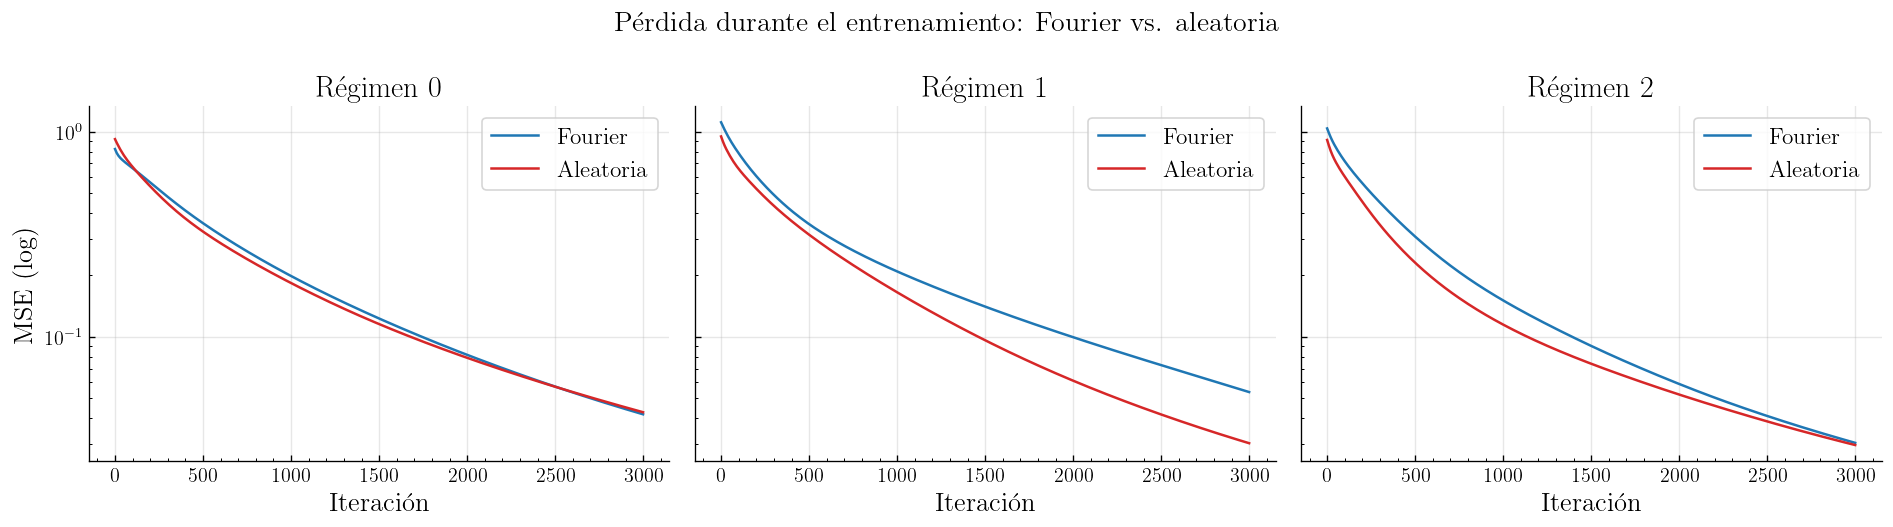

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for r, ax in zip(REGIMES, axes):
    for label, color in [("fourier", "C0"), ("random", "C3")]:
        _, losses = results[r][label]
        iters = [p[0] for p in losses]
        vals = [p[1] for p in losses]
        ax.plot(iters, vals, label=("Fourier" if label == "fourier" else "Aleatoria"), color=color)
    ax.set_title(f"Régimen {r}")
    ax.set_xlabel("Iteración")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("MSE (log)")
fig.suptitle("Pérdida durante el entrenamiento: Fourier vs. aleatoria")
plt.tight_layout()
plt.show()


### Velocidad de convergencia (foco en el régimen 0)

Para comparar objetivamente la *velocidad*, se mide en qué iteración cada curva cruza por primera vez un umbral cercano a su pérdida final (95% de la reducción total lograda). Un número de iteración menor significa convergencia más rápida.

In [35]:
def iter_para_umbral(losses, frac=0.95):
    '''Iteración en la que la pérdida ya bajó `frac` de la reducción total
    (desde la pérdida inicial hasta la final). frac=0.95 -> ha recorrido
    el 95% del camino hacia su valor final.'''
    iters = np.array([p[0] for p in losses])
    vals = np.array([p[1] for p in losses])
    l0, lf = vals[0], vals[-1]
    objetivo = l0 - frac * (l0 - lf)
    idx = np.argmax(vals <= objetivo)  # primer indice que cumple
    return int(iters[idx]) if vals[idx] <= objetivo else int(iters[-1])


print(f"{'Régimen':<10}{'Init':<12}{'Pérdida inicial':<18}{'Pérdida final':<16}{'Iter. al 95% de mejora':<24}")
for r in REGIMES:
    for label in ["fourier", "random"]:
        _, losses = results[r][label]
        l0 = losses[0][1]
        lf = losses[-1][1]
        it95 = iter_para_umbral(losses)
        nombre = "Fourier" if label == "fourier" else "Aleatoria"
        print(f"{r:<10}{nombre:<12}{l0:<18.5f}{lf:<16.5f}{it95:<24}")

print()
print("Régimen 0 en detalle:")
for label in ["fourier", "random"]:
    _, losses = results[0][label]
    nombre = "Fourier" if label == "fourier" else "Aleatoria"
    print(f"  {nombre}: pérdida inicial={losses[0][1]:.5f}, pérdida en iter 100={dict(losses).get(100, 'n/a')}")


Régimen   Init        Pérdida inicial   Pérdida final   Iter. al 95% de mejora  
0         Fourier     0.82354           0.04186         2020                    
0         Aleatoria   0.92035           0.04284         1870                    
1         Fourier     1.11200           0.05373         1900                    
1         Aleatoria   0.94861           0.03025         1750                    
2         Fourier     1.03791           0.03037         1630                    
2         Aleatoria   0.91214           0.02964         1510                    

Régimen 0 en detalle:
  Fourier: pérdida inicial=0.82354, pérdida en iter 100=0.6635728478431702
  Aleatoria: pérdida inicial=0.92035, pérdida en iter 100=0.6733996868133545


## Reconstrucción de señales

Se compara, para una señal de ejemplo de cada régimen, la señal original $x$ contra la reconstrucción $\hat x$ obtenida por la red **ya entrenada**, con ambas inicializaciones.

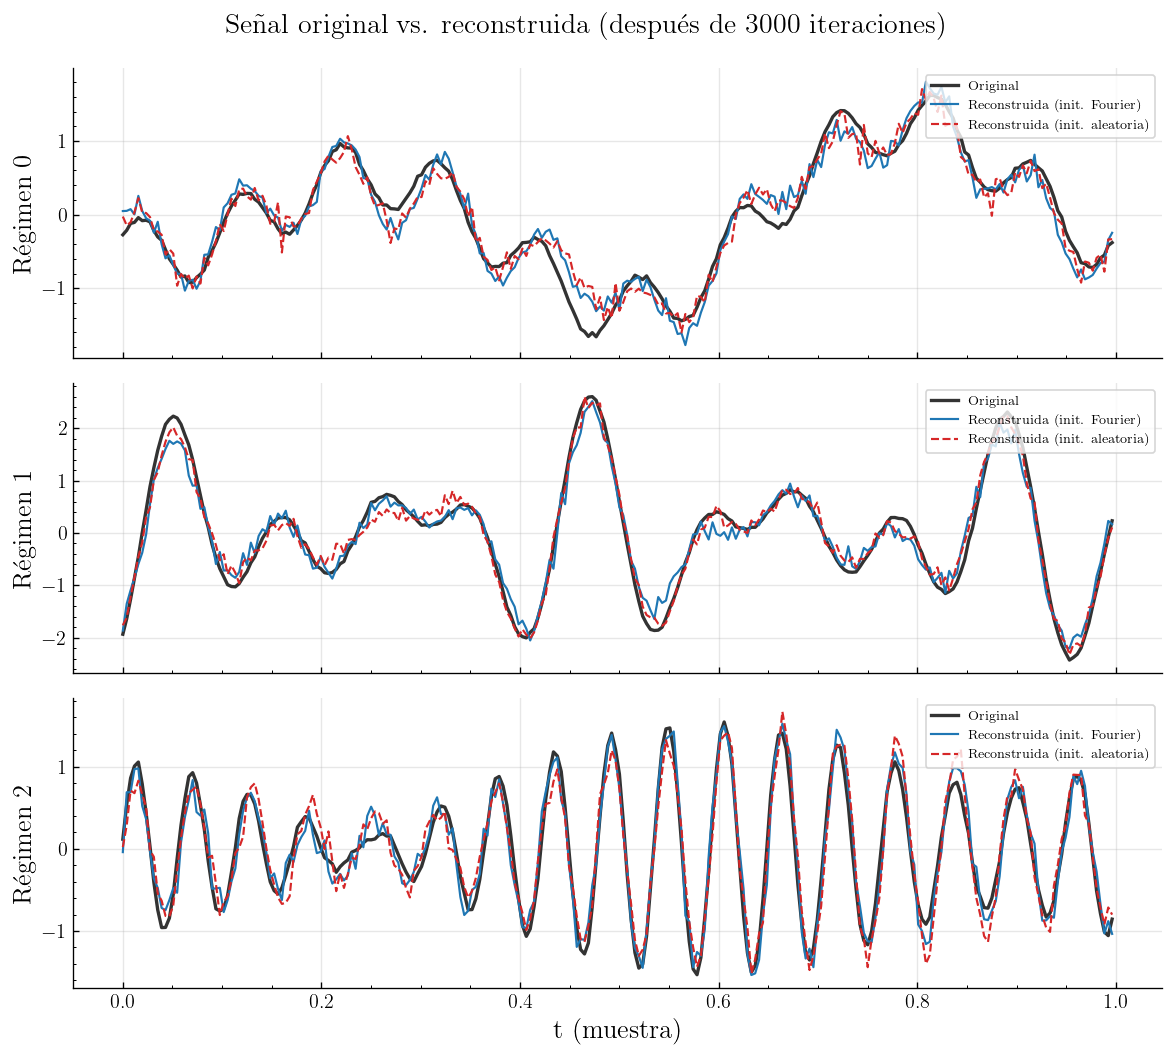

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for r, ax in zip(REGIMES, axes):
    x_ejemplo = jnp.array(data_by_regime[r][0])
    p_f = results[r]["fourier"][0]
    p_r = results[r]["random"][0]
    xhat_f = forward(p_f, x_ejemplo)
    xhat_r = forward(p_r, x_ejemplo)

    ax.plot(t[:N], np.array(x_ejemplo), color="k", lw=2, label="Original", alpha=0.8)
    ax.plot(t[:N], np.array(xhat_f), color="C0", lw=1.3, label="Reconstruida (init. Fourier)")
    ax.plot(t[:N], np.array(xhat_r), color="C3", lw=1.3, ls="--", label="Reconstruida (init. aleatoria)")
    ax.set_ylabel(f"Régimen {r}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("t (muestra)")
fig.suptitle("Señal original vs. reconstruida (después de 3000 iteraciones)")
plt.tight_layout()
plt.show()

## Compresión: energía en la capa Fourier

¿Cuánta información de la señal vive en pocos coeficientes de la capa Fourier? Se calcula, para cada señal, la energía de cada uno de los `2K` coeficientes $(W_1 x)_i^2$ usando la matriz de Fourier fija (antes de entrenar), se ordena de mayor a menor, se acumula, y se mide en qué número de coeficiente se alcanza el **95%** de la energía total. Esto se hace para **todas las señales de cada régimen** (no solo un ejemplo) y se reporta el promedio.

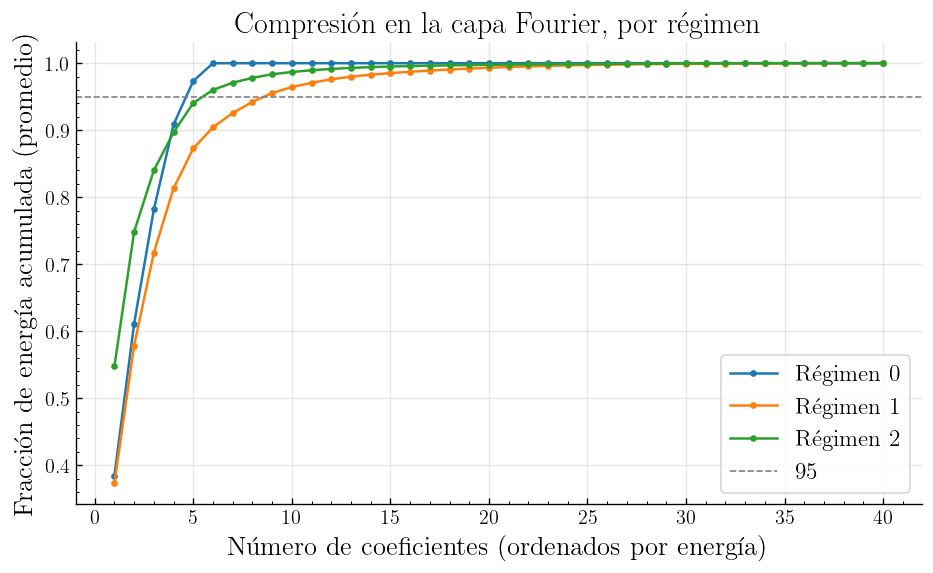

Régimen   Coefs. para 95% energía (promedio ± std, de 2K=40)     
0         4.9 ± 0.7
1         8.8 ± 3.2
2         5.5 ± 2.0


In [37]:
def coeficientes_para_energia(x, frac=0.95):
    '''Numero minimo de coeficientes (ordenados por energia) de la capa
    Fourier fija que acumulan al menos `frac` de la energia total de x.'''
    coef = W1_fourier @ np.asarray(x)          # (2K,) proyeccion de Fourier
    energia = coef ** 2
    energia_ordenada = np.sort(energia)[::-1]
    acumulada = np.cumsum(energia_ordenada)
    total = acumulada[-1]
    fracciones = acumulada / total
    m = int(np.searchsorted(fracciones, frac) + 1)
    return m, fracciones


resumen_compresion = {}
fig, ax = plt.subplots(figsize=(8, 5))
for r in REGIMES:
    ms = []
    curva_prom = np.zeros(TWO_K)
    for x in data_by_regime[r]:
        m, fracciones = coeficientes_para_energia(x)
        ms.append(m)
        curva_prom += fracciones
    curva_prom /= len(data_by_regime[r])
    resumen_compresion[r] = {"m95_promedio": np.mean(ms), "m95_std": np.std(ms)}
    ax.plot(np.arange(1, TWO_K + 1), curva_prom, marker="o", ms=3, label=f"Régimen {r}")

ax.axhline(0.95, color="gray", ls="--", lw=1, label="95% de energía")
ax.set_xlabel("Número de coeficientes (ordenados por energía)")
ax.set_ylabel("Fracción de energía acumulada (promedio)")
ax.set_title("Compresión en la capa Fourier, por régimen")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'Régimen':<10}{'Coefs. para 95% energía (promedio ± std, de 2K='+str(TWO_K)+')':<55}")
for r in REGIMES:
    info = resumen_compresion[r]
    print(f"{r:<10}{info['m95_promedio']:.1f} ± {info['m95_std']:.1f}")


## Conclusiones



- **Régimen 0**: la inicialización Fourier termina con una pérdida final ligeramente mejor (0.0419 vs. 0.0428) y arranca con menor error en las primeras iteraciones (0.664 vs. 0.673 en la iteración 100). Esto sí es consistente con la intuición: al no haber dispersión, la base de Fourier ya es (casi) la base correcta.

- **Régimen 1**: aquí la inicialización aleatoria terminó con una pérdida final claramente mejor que Fourier (0.0303 vs. 0.0537, casi la mitad). Esto contradice la afirmación genérica de que "ambas inicializaciones tienden a converger a pérdidas finales parecidas"; en este régimen no fue así con los datos reales.

- **Régimen 2**: las pérdidas finales quedaron muy cerca entre sí (0.0304 vs. 0.0296), con ligera ventaja para la aleatoria.

**Conclusión:** la ventaja de partir en la base de Fourier se observa sobre todo en el régimen sin dispersión (régimen 0), tanto en velocidad temprana como en el resultado final, aunque por un margen pequeño. En los regímenes con dispersión (1 y 2) la ventaja no se sostiene de forma consistente e incluso se invierte en el régimen 1. Esto sugiere que, si bien la intuición teórica (Fourier ayuda cuando la señal realmente vive en esa base) tiene sentido, con solo 15 señales por régimen y una sola corrida por configuración, el resultado empírico está sujeto a variabilidad y no permite afirmar una ventaja uniforme de Fourier fuera del régimen 0. Una forma de fortalecer esta conclusión sería repetir el entrenamiento con varias semillas y reportar el promedio ± desviación estándar de la pérdida final, en lugar de una sola corrida por inicialización.